In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
N_SEGS = 12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')




def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS))
        except Exception:
            pass
    return out


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u


Using dt=5s, T=1.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris1_sc/int_1yr_s12'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.498025  ,  0.562075  ,  0.822955  ,  0.390465  ,  0.596415  ],
        [ 0.50468562,  0.5726022 ,  0.83840384,  0.39258511,  0.60597373],
        [ 0.49556852,  0.56715114,  0.81116578,  0.37926781,  0.59244115],
        ...,
        [ 0.32514631,  0.3942078 ,  0.69107019,  0.27480762,  1.06024562],
        [ 0.3095975 ,  0.3092017 ,  0.64547689,  1.12179411,  1.07856524],
        [ 0.85266912,  0.33322873,  0.51634563, -0.38318295,  0.06082123]])]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([16.30437917, 14.85051465, 15.16791047, ...,        -inf,
               -inf,        -inf])]

In [7]:
sampler.now_covariances

[array([[ 0.04717521,  0.042774  , -0.0321179 , -0.0425167 ,  0.00611756],
        [ 0.042774  ,  0.21319327, -0.0126961 ,  0.00417553,  0.0067059 ],
        [-0.0321179 , -0.0126961 ,  0.2934893 , -0.00260203,  0.0062287 ],
        [-0.0425167 ,  0.00417553, -0.00260203,  0.1830377 ,  0.00376639],
        [ 0.00611756,  0.0067059 ,  0.0062287 ,  0.00376639,  0.27416401]])]

In [8]:
np.argmax(logden_list)

10

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.99872048, 1.08372831, 0.86628064, 9.17494943, 0.3773804 ]])

In [10]:
log_density(maxld_pt1)

array([16.88954386])

In [11]:
log_density([param_true])

array([28.6893345])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

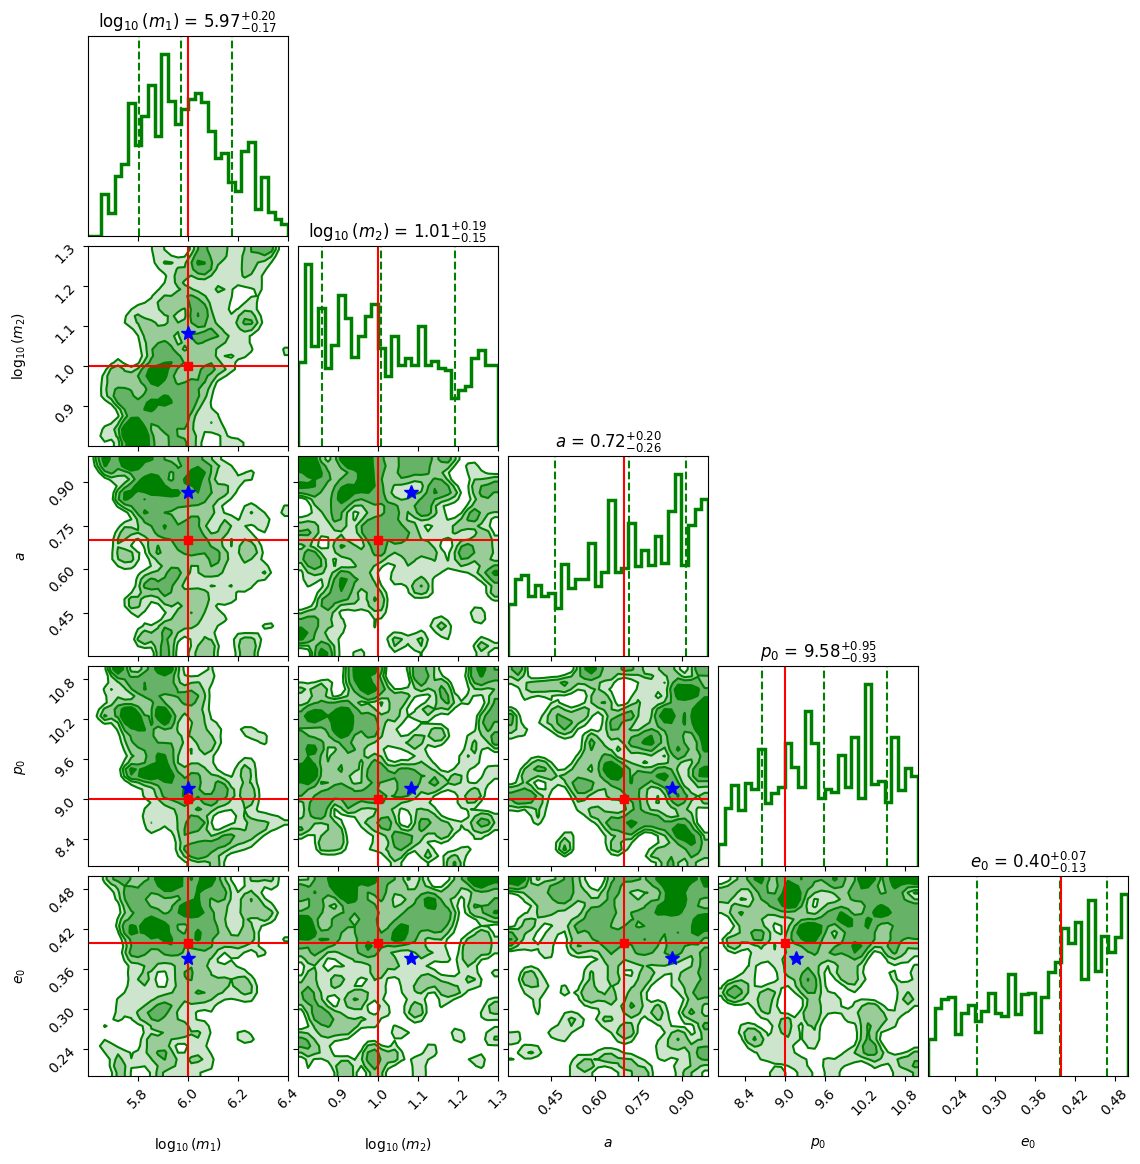

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
np.sort(logden_list)

array([[       -inf,        -inf,        -inf, ..., 16.46441263,
        16.50109232, 16.88954386]])

In [16]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([  10,  846, 1251,  121,    0,    5,  494, 1627, 2722,   92])

In [17]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[ 5.99872048,  1.08372831,  0.86628064,  9.17494943,  0.3773804 ],
       [ 5.9602631 ,  1.01893681,  0.74289819,  9.48761618,  0.41222301],
       [ 5.94344828,  1.0650786 ,  0.76445971,  9.87432457,  0.40045439],
       [ 5.99217863,  1.077527  ,  0.88396926,  9.21660037,  0.38895047],
       [ 5.99842   ,  1.0810375 ,  0.86783895,  9.171395  ,  0.3789245 ],
       [ 6.00438277,  1.09482128,  0.87889901,  9.13485519,  0.37267362],
       [ 6.00922023,  1.09077257,  0.89551036,  9.0370425 ,  0.37571677],
       [ 5.86659069,  0.98211089,  0.89617391, 10.65788183,  0.41984796],
       [ 5.77241504,  0.82271002,  0.95587114,  9.31705273,  0.41660302],
       [ 6.01007057,  1.11122358,  0.89352529,  9.12001165,  0.36754544]])

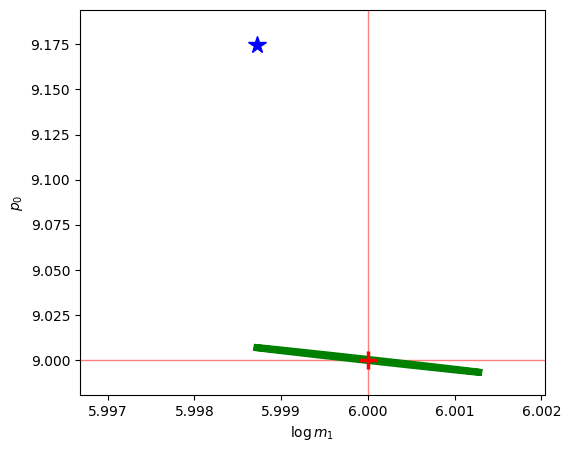

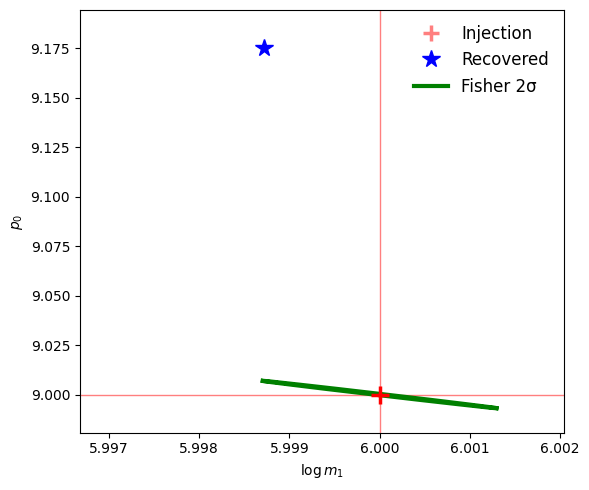

In [18]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

with open('/home/svu/e1498138/emri_search/work/search/cov_matrix_noise_1yr.pkl', 'rb') as f:
    cov = pickle.load(f)

def draw_cov_ellipse(ax, cx, cy, cov2d, n_sigma=1, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ell = Ellipse(xy=(cx, cy),
                width=2 * n_sigma * np.sqrt(vals[0]),
                height=2 * n_sigma * np.sqrt(vals[1]),
                angle=angle, **kwargs)
    ax.add_patch(ell)

_pt  = np.asarray(param_true).ravel()
_map = np.asarray(maxld_pt1).ravel()
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]

xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=5, zorder=2)

ax.set_xlabel(r'$\log m_1$')
ax.set_ylabel(r'$p_0$')
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]
a
xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=3, zorder=2)

ax.set_xlabel(r'$\log  m_1$')
ax.set_ylabel(r'$p_0$')

legend_handles = [
    Line2D([0], [0], color='red',   marker='+', ls='', ms=12, mew=2.5, alpha=0.5, label='Injection'),
    Line2D([0], [0], color='blue',  marker='*', ls='', ms=13,           label='Recovered'),
    Line2D([0], [0], color='green', ls='-',  lw=3,                      label='Fisher 2σ'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

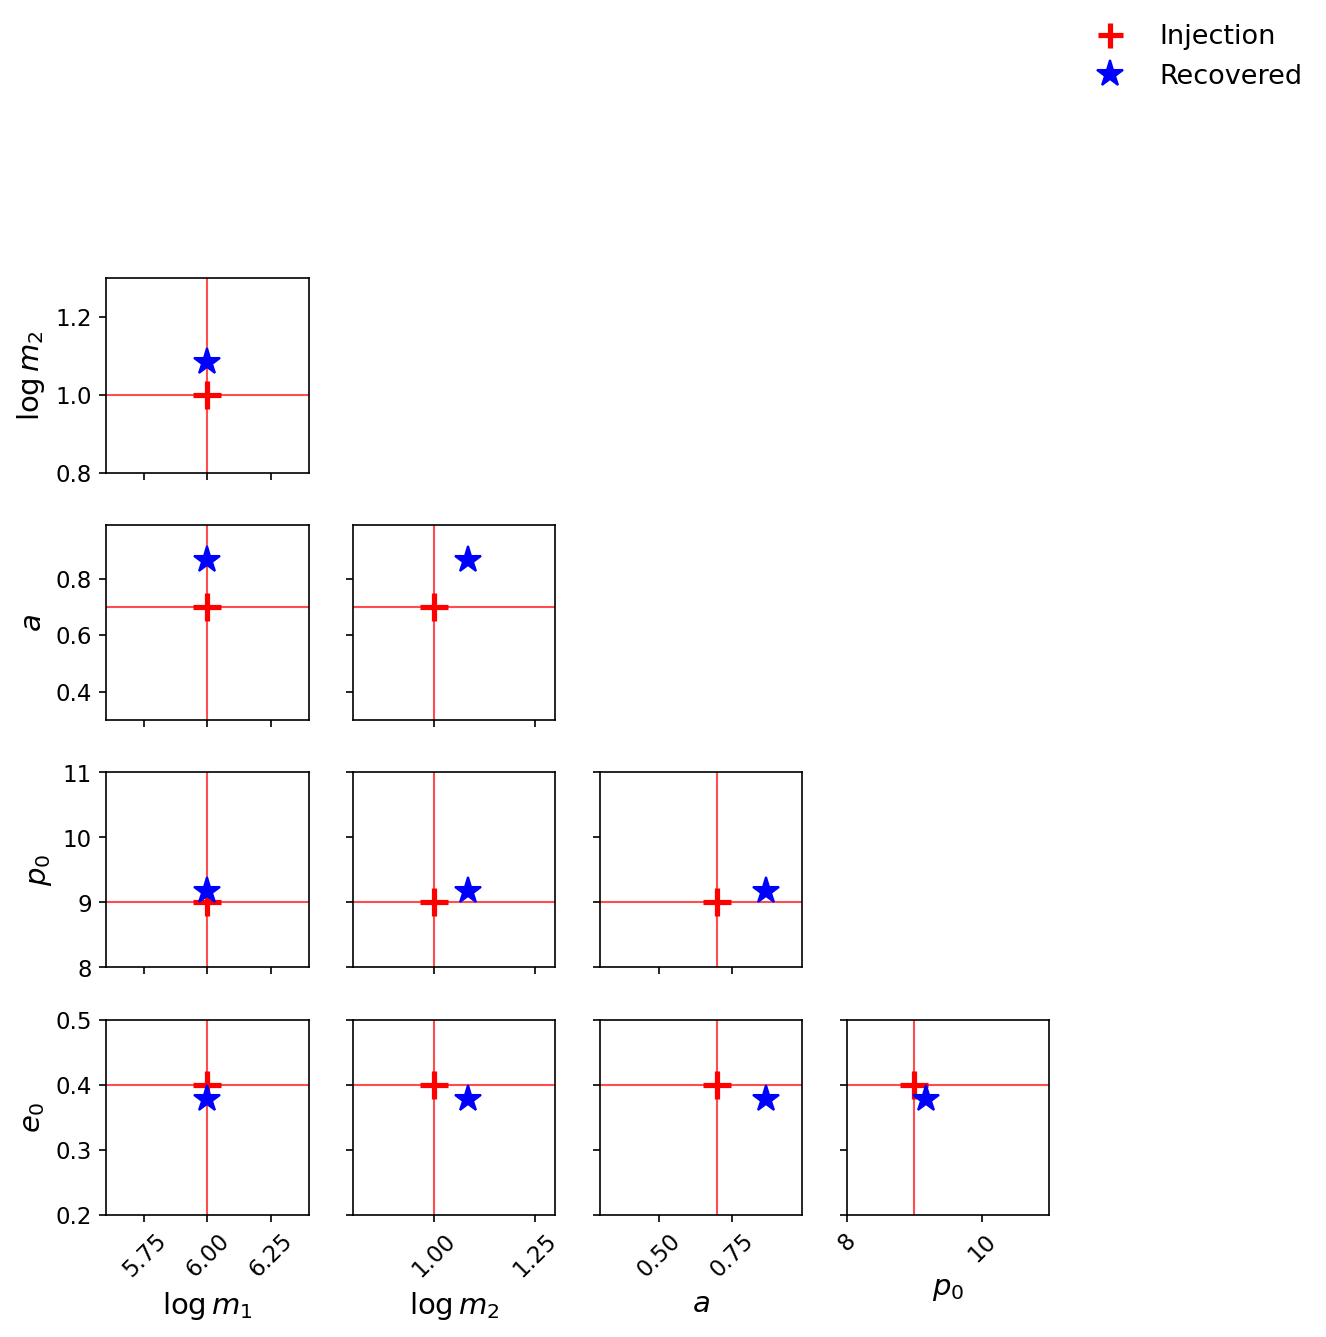

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

In [ ]:
np.average(top10_pts.T[0])

5.955570979410169

In [ ]:
np.average(top10_pts.T[1])

1.0427946564632424

In [ ]:
np.average(top10_pts.T[2])

0.8645426475686746

In [ ]:
np.average(top10_pts.T[3])

9.419172944493516

In [ ]:
np.average(top10_pts.T[4])

0.391031958423387

In [ ]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [ ]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [ ]:
import matplotlib.pyplot as plt

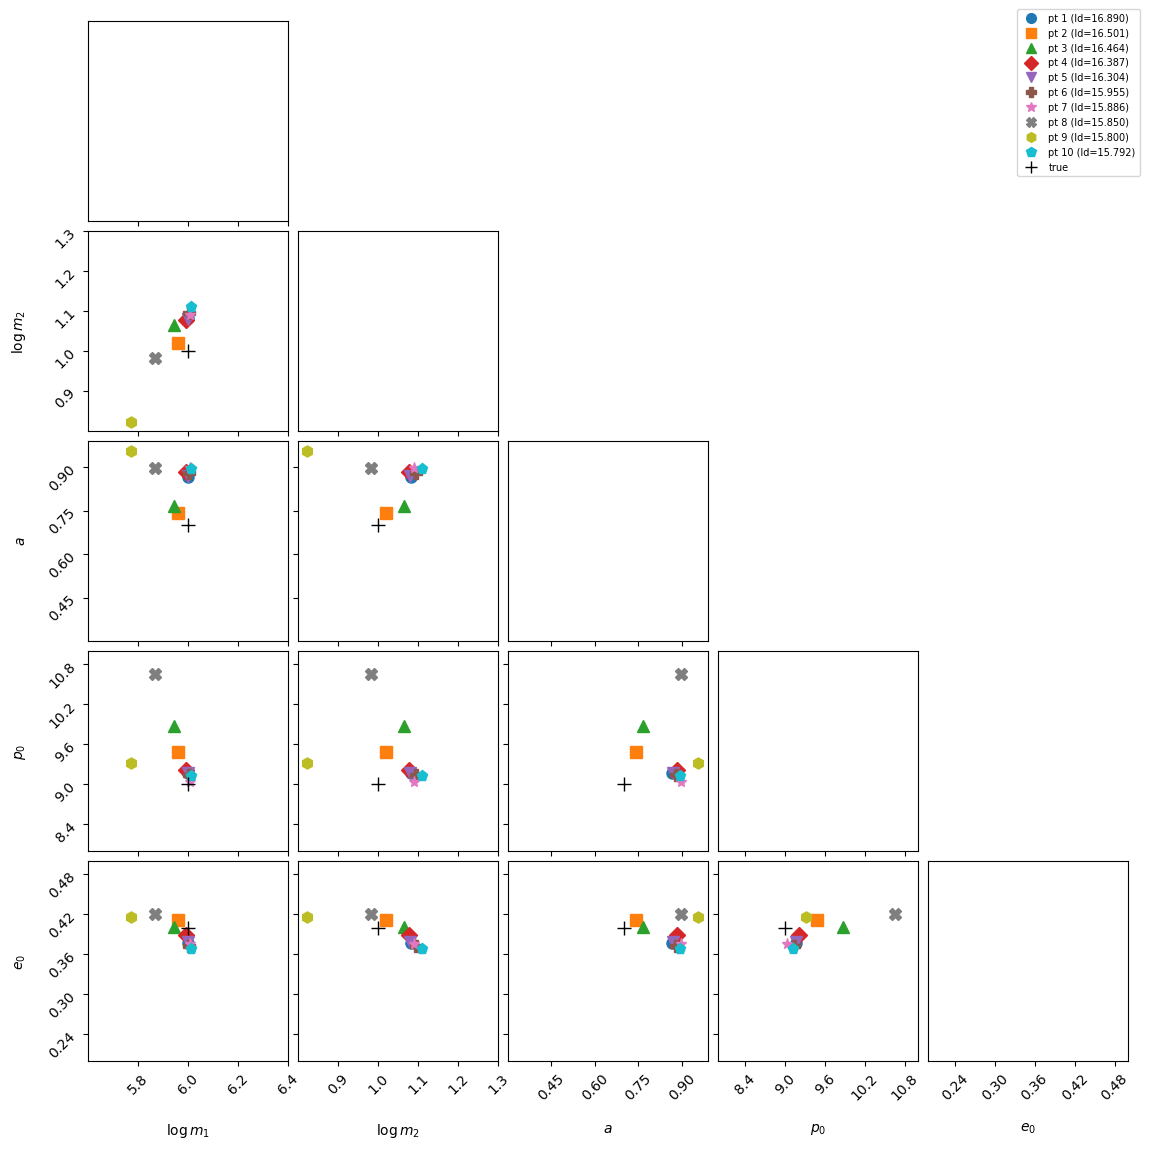

In [26]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

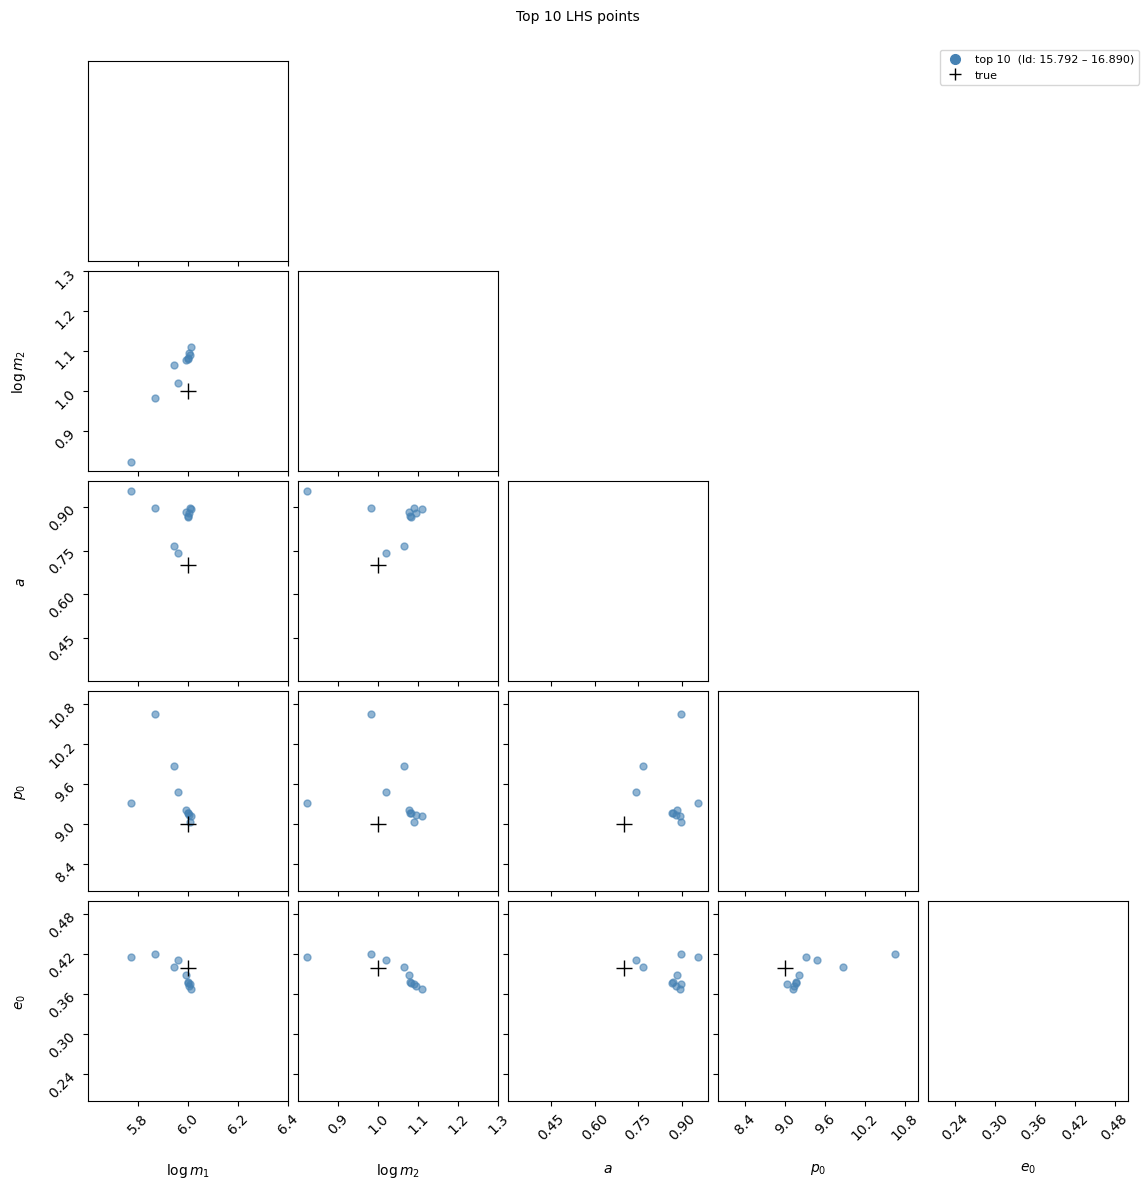

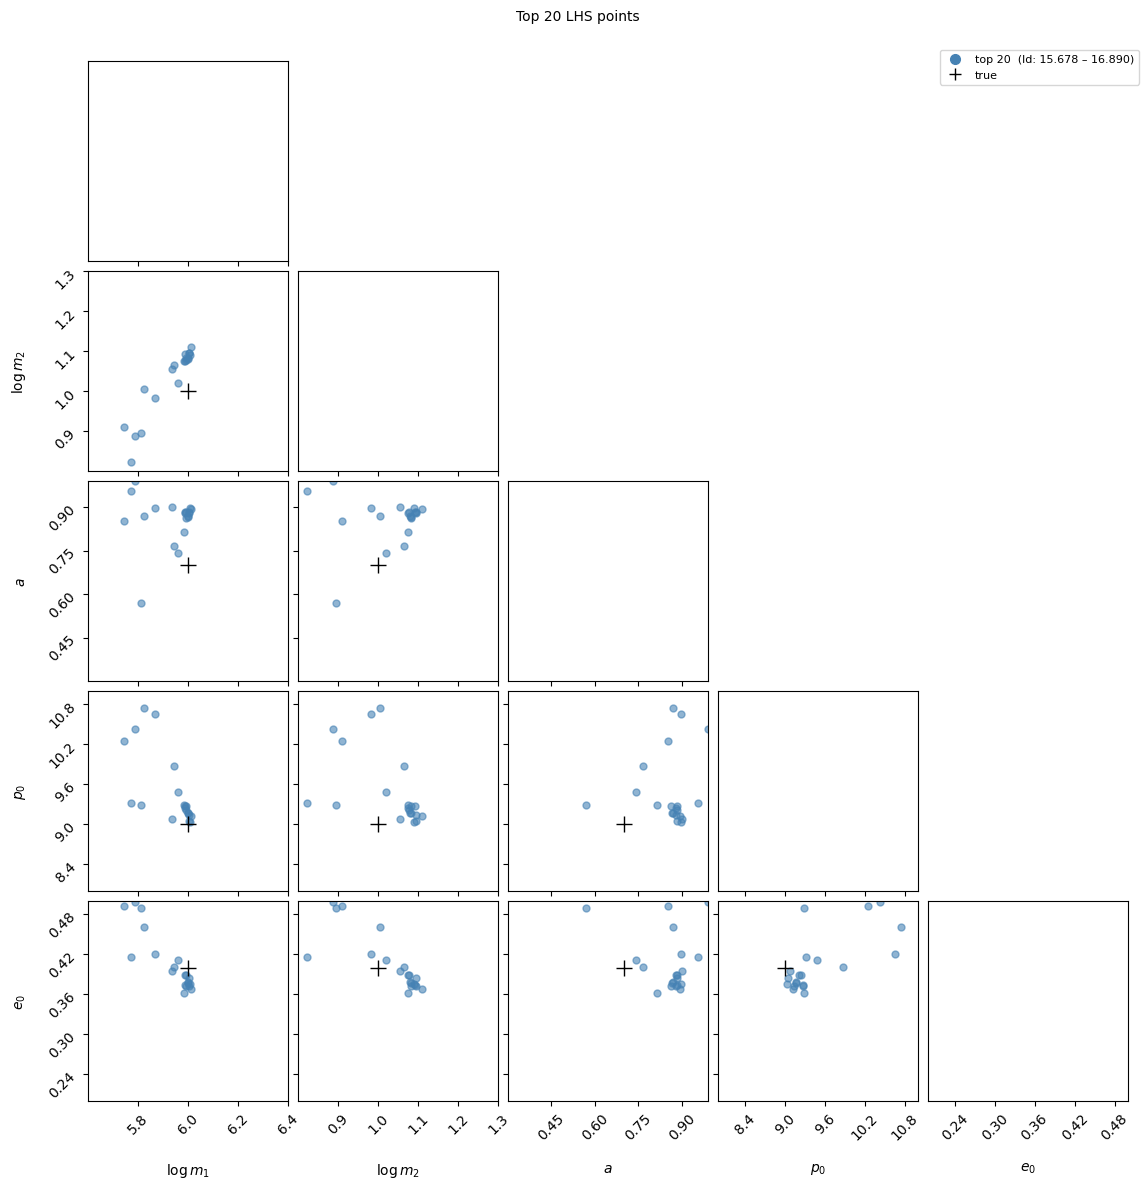

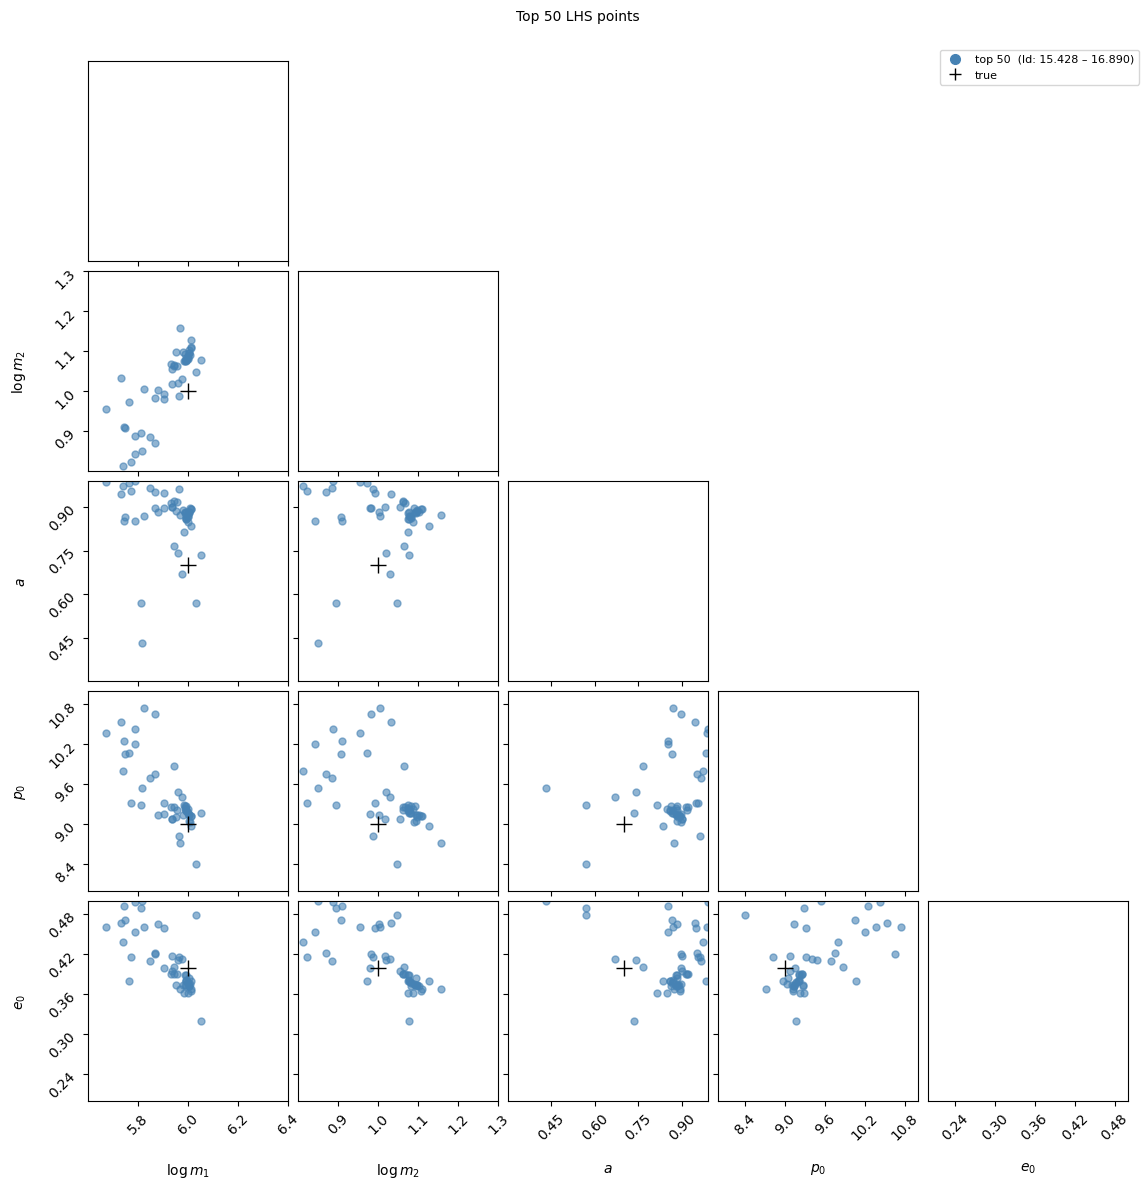

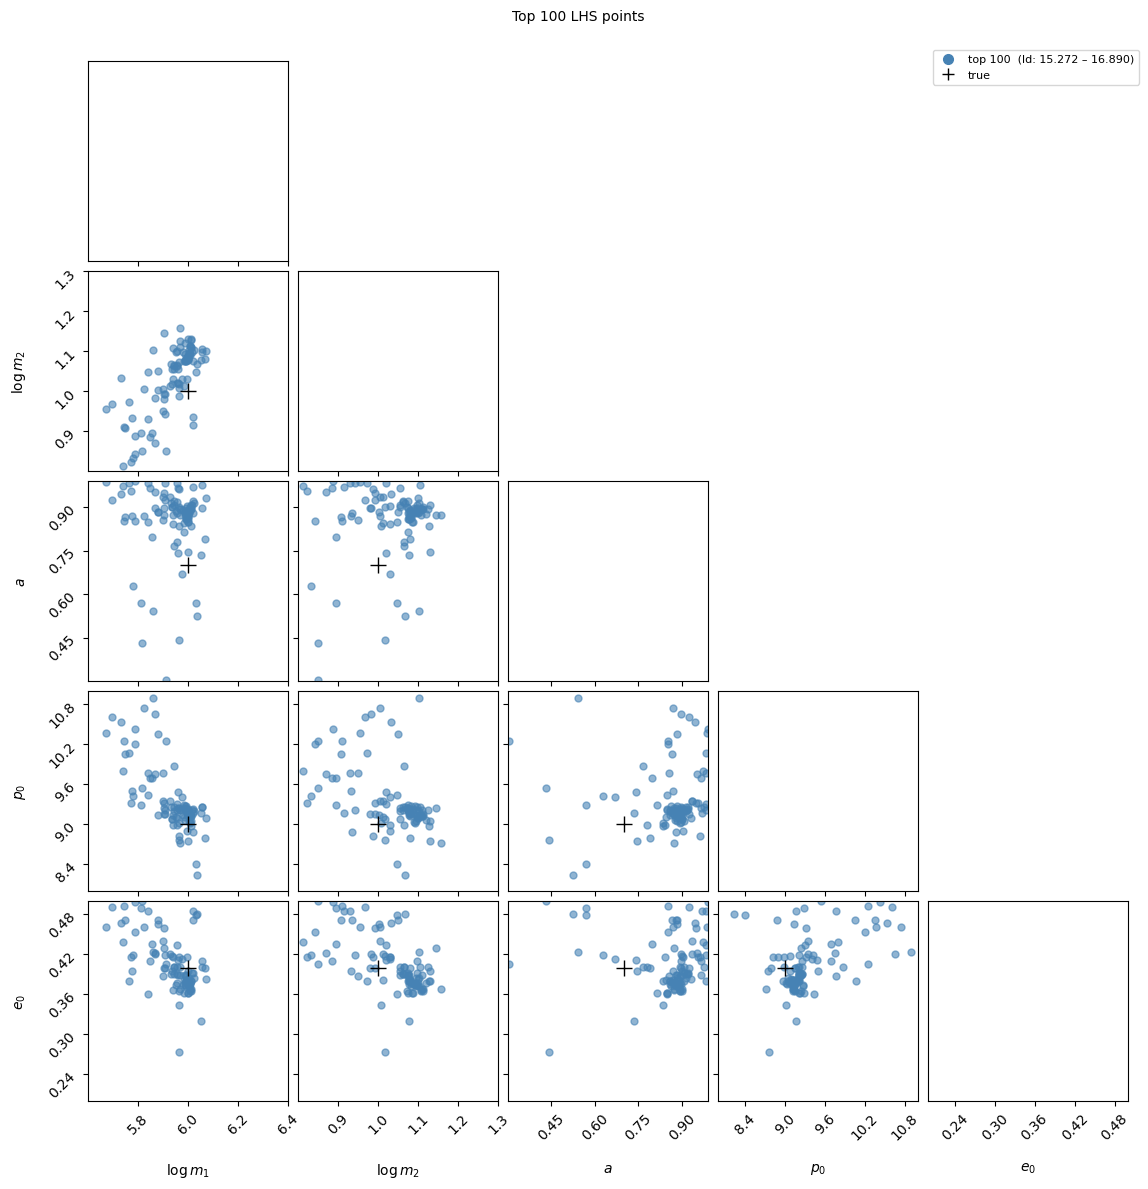

In [27]:
from matplotlib.lines import Line2D

all_logden = np.concatenate(logden_list)
sorted_idx = np.argsort(all_logden).flatten()

def plot_topN(N, color='steelblue', marker='o', ms=5):
    idx = sorted_idx[-N:][::-1]
    pts = prior_transform(proc_pt[0][idx])
    ld_vals = all_logden[idx]

    all_pts = np.vstack([pts, [true_params]])
    fig = corner.corner(all_pts, labels=labels, show_titles=False,
                        plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                        hist_kwargs=dict(alpha=0, lw=0))

    corner.overplot_points(fig, pts, color=color, marker=marker, ms=ms, alpha=0.6)
    corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=12, zorder=10)

    axes_arr = np.array(fig.axes).reshape((ndim, ndim))
    for row in range(ndim):
        for col in range(ndim):
            if col <= row:
                axes_arr[row, col].set_xlim(ranges[col])
            if col < row:
                axes_arr[row, col].set_ylim(ranges[row])

    handles = [
        Line2D([0],[0], color=color, marker=marker, ls='', ms=7,
                label=f'top {N}  (ld: {ld_vals[-1]:.3f} – {ld_vals[0]:.3f})'),
        Line2D([0],[0], color='black', marker='+', ls='', ms=9, label='true'),
    ]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=8)
    fig.suptitle(f'Top {N} LHS points', fontsize=10, y=1.01)
    plt.show()

for N in [10, 20, 50, 100]:
    plot_topN(N)

# connection plot

In [ ]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.99872048, 1.08372831, 0.86628064, 9.17494943, 0.3773804 ]])

In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [30]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [32]:
logden_theory_proc1

array([16.88954386, 16.85145444, 16.72034062, 16.89837327, 16.05800398,
       16.19862976, 16.84099552, 16.12607641, 16.70940398, 16.89948136,
       16.36804665, 16.27465763, 16.3496144 , 16.66352833, 16.48471548,
       16.65132114, 16.25464021, 17.05886366, 16.52674268, 16.12762135,
       16.56460426, 16.61530783, 16.31259113, 16.54892565, 16.18749228,
       15.92117852, 16.07726654, 15.99777838, 15.83699322, 16.91956718,
       16.70773706, 16.72641897, 16.24758719, 16.58290779, 16.45534304,
       16.89762965, 16.75283042, 16.97870165, 16.79603898, 16.62131318,
       16.88992719, 16.63513567, 16.30452368, 16.50613403, 16.10296884,
       16.01020196, 17.30226252, 16.40780057, 16.57940712, 28.6893345 ])

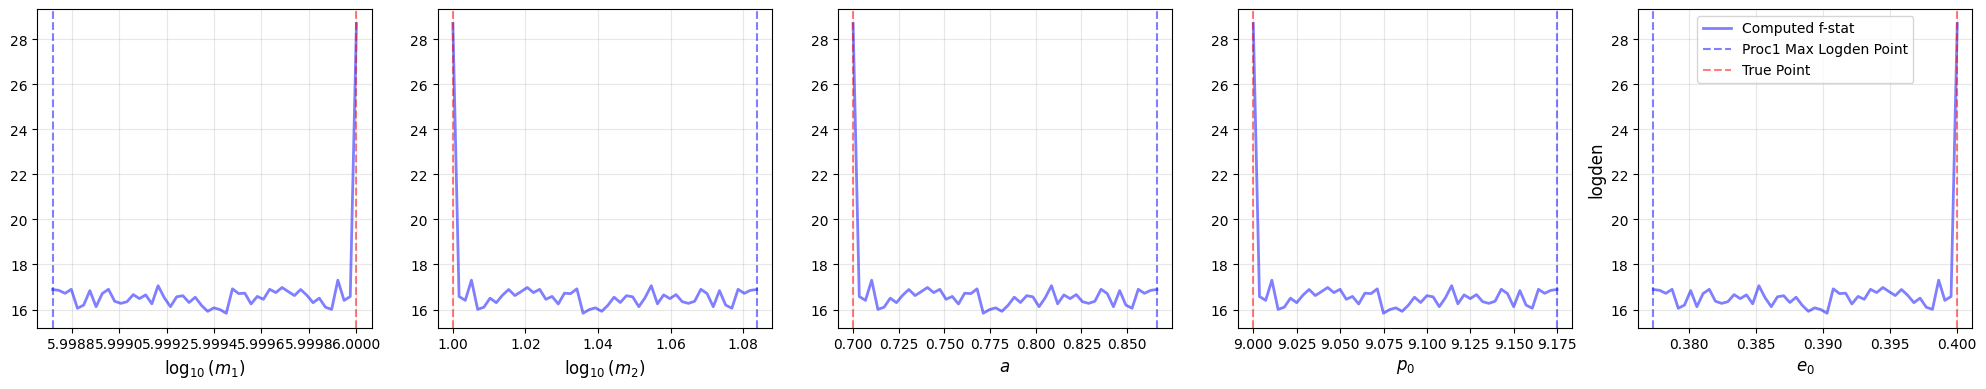

In [33]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [34]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [35]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [36]:
logden_tm = log_density(line_points_logm1.T)


In [37]:
logden_tm

array([       -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,      

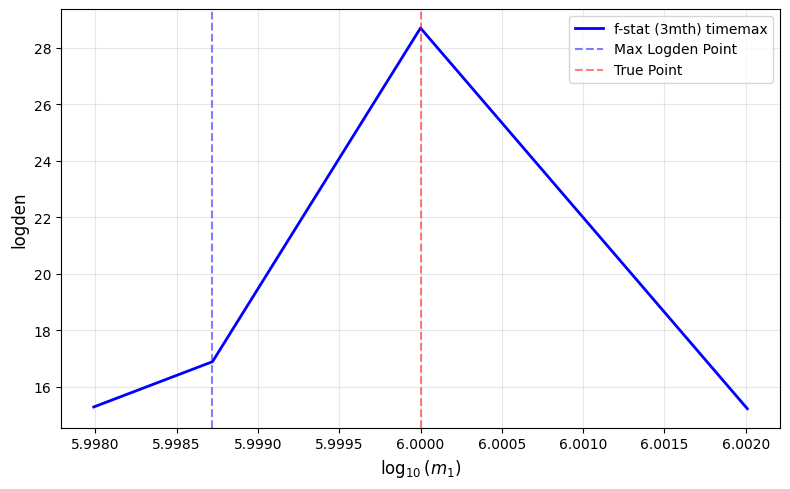

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='f-stat (3mth) timemax')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()